In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

Using TensorFlow backend.
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:523: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:524: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:525: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/t

In [4]:




#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/Dataset/dataset_training_no_aug.h5"
#"/workspaces/work/Dataset/dataset_training_no_aug.h5"



In [5]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,5000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [6]:



data = awgn(data, snr_range)

In [ ]:
print(data)

In [7]:
import numpy as np

def apply_random_shift(data, max_shift):
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(data, shift, axis=1)

def apply_random_noise(data, noise_level):
    noise = np.random.normal(scale=noise_level, size=data.shape)
    return data + noise

# Example usage
max_shift = 10
noise_level = 0.1

# Apply random shift and noise to a single sample
augmented_sample = apply_random_shift(data, max_shift)
augmented_sample = apply_random_noise(augmented_sample, noise_level)


(5000, 8192)

In [6]:
data.shape

(5000, 8192)

/opt/conda/envs/project/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


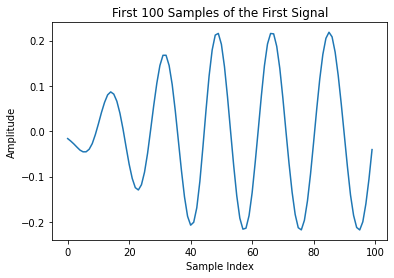

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace this with your actual data)
data = data  # Simulated data

# Plot the first few samples of the first signal
plt.plot(data[0, :100])
plt.title('First 100 Samples of the First Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

/opt/conda/envs/project/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


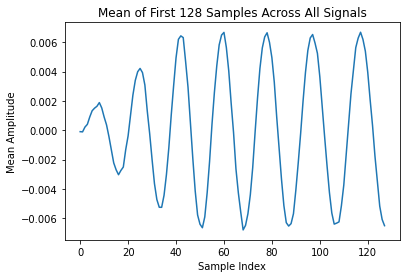

Suspected Preamble: [-9.81418907e-05+8.30126950e-04j -1.11516083e-04+1.01712305e-03j
  2.15650277e-04+1.15618110e-03j  3.99976252e-04+1.36031529e-03j
  9.02134543e-04+1.24035604e-03j  1.32689755e-03+6.99611635e-04j
  1.50268081e-03+4.93028389e-04j  1.63147339e-03-6.51224105e-06j
  1.88424732e-03-7.40983333e-04j  1.51944188e-03-1.32171043e-03j
  9.00842573e-04-1.72586020e-03j  3.64517050e-04-2.45407674e-03j
 -4.30562137e-04-2.40926933e-03j -1.33441266e-03-2.09166708e-03j
 -2.22558176e-03-1.44208949e-03j -2.69459788e-03-8.31437142e-04j
 -3.03083719e-03+1.73323182e-04j -2.74043466e-03+1.15585940e-03j
 -2.50848656e-03+2.11675788e-03j -1.32768257e-03+3.06875998e-03j
 -3.87639047e-04+3.37142448e-03j  9.97823536e-04+3.61103455e-03j
  2.39042429e-03+3.10988438e-03j  3.39440593e-03+2.09193490e-03j
  3.98474264e-03+6.83534210e-04j  4.21001145e-03-7.29113993e-04j
  3.92603584e-03-2.30377455e-03j  3.07881039e-03-3.60481297e-03j
  1.30536845e-03-4.52429898e-03j -2.27818580e-04-4.83026898e-03j
 -1.9

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `data` is a NumPy array with shape (30000, 8192)

# Calculate the mean of the first 128 samples across all signals to detect a common pattern
N = 128  # Length of the suspected preamble
mean_pattern = np.mean(data[:, :N], axis=0)

# Plot the mean pattern to visually inspect it
plt.plot(mean_pattern)
plt.title('Mean of First 128 Samples Across All Signals')
plt.xlabel('Sample Index')
plt.ylabel('Mean Amplitude')
plt.show()

# Output the suspected preamble
suspected_preamble = mean_pattern
print("Suspected Preamble:", suspected_preamble)


/opt/conda/envs/project/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


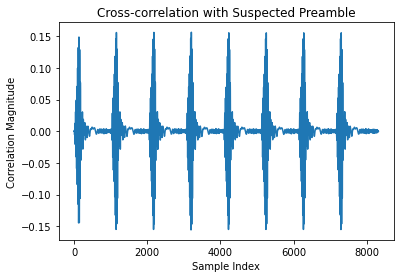

Peak correlation index: 3202
Peak correlation value: (0.02493717827659475+0.1559369131954691j)
Synchronized signal start index: 3075


In [14]:
# Example: Cross-correlation to verify the suspected preamble

# Use the first signal for cross-correlation
received_signal = data[0]

# Perform cross-correlation
correlation = np.correlate(received_signal, suspected_preamble, mode='full')
peak_index = np.argmax(np.abs(correlation))

# Plot the correlation result
plt.plot(correlation)
plt.title('Cross-correlation with Suspected Preamble')
plt.xlabel('Sample Index')
plt.ylabel('Correlation Magnitude')
plt.show()

# Output the index of the maximum correlation value
print(f"Peak correlation index: {peak_index}")
print(f"Peak correlation value: {correlation[peak_index]}")

# Check if the peak is significant and verify the preamble
start_index = peak_index - len(suspected_preamble) + 1
synchronized_signal = received_signal[start_index:]

print(f"Synchronized signal start index: {start_index}")


In [17]:
import numpy as np

# Given values
peak_index =3202
preamble_length = 128  # Assuming preamble length, adjust as needed
start_index = peak_index - preamble_length + 1

# Example received signal (replace with actual data)
received_signal = data[0]  # Using the first signal for illustration

# Extract the suspected preamble from the synchronized signal
suspected_preamble = received_signal[start_index:start_index + preamble_length]

print("Suspected Preamble:", suspected_preamble)
print("Synchronized signal start index:", start_index)


Suspected Preamble: [-0.17286124+0.13317601j -0.15777589+0.15069865j -0.13488605+0.17199457j
 -0.10241657+0.19384757j -0.06000994+0.21109231j -0.00931689+0.21954229j
  0.04825744+0.21389851j  0.10409675+0.19291209j  0.15533322+0.15441641j
  0.19476911+0.09979547j  0.21602364+0.03607826j  0.2165013 -0.03535573j
  0.19333731-0.10415971j  0.14823376-0.16250906j  0.08562223-0.20246492j
  0.01251144-0.21966611j -0.06438307-0.20992702j -0.13223138-0.17492628j
 -0.18444748-0.11801482j -0.21412747-0.04567928j -0.2164271 +0.0320619j
 -0.19124725+0.10701255j -0.14010507+0.16868186j -0.07232568+0.20747402j
  0.00467886+0.21989191j  0.08440752+0.20340446j  0.15273038+0.15829082j
  0.1987531 +0.09395621j  0.21907678+0.01528764j  0.20987783-0.06338269j
  0.17342107-0.13388601j  0.11352302-0.1872493j   0.03988326-0.21536999j
 -0.03826213-0.21595201j -0.11269155-0.18822482j -0.17356475-0.13481977j
 -0.20959965-0.06563933j -0.2196869 +0.01208839j -0.20050896+0.09012582j
 -0.15467133+0.15579148j -0.0892

In [18]:
preamble=suspected_preamble
data_input=data

In [19]:
preamble

array([-0.17286124+0.13317601j, -0.15777589+0.15069865j,
       -0.13488605+0.17199457j, -0.10241657+0.19384757j,
       -0.06000994+0.21109231j, -0.00931689+0.21954229j,
        0.04825744+0.21389851j,  0.10409675+0.19291209j,
        0.15533322+0.15441641j,  0.19476911+0.09979547j,
        0.21602364+0.03607826j,  0.2165013 -0.03535573j,
        0.19333731-0.10415971j,  0.14823376-0.16250906j,
        0.08562223-0.20246492j,  0.01251144-0.21966611j,
       -0.06438307-0.20992702j, -0.13223138-0.17492628j,
       -0.18444748-0.11801482j, -0.21412747-0.04567928j,
       -0.2164271 +0.0320619j , -0.19124725+0.10701255j,
       -0.14010507+0.16868186j, -0.07232568+0.20747402j,
        0.00467886+0.21989191j,  0.08440752+0.20340446j,
        0.15273038+0.15829082j,  0.1987531 +0.09395621j,
        0.21907678+0.01528764j,  0.20987783-0.06338269j,
        0.17342107-0.13388601j,  0.11352302-0.1872493j ,
        0.03988326-0.21536999j, -0.03826213-0.21595201j,
       -0.11269155-0.18822482j,

In [20]:
import numpy as np




# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...


Most Common Synchronization Offset: 1023


/opt/conda/envs/project/lib/python3.6/site-packages/ipykernel_launcher.py:26: ComplexWarning: Casting complex values to real discards the imaginary part


In [22]:
import numpy as np

def generate_pilot_sequence(preamble_array):
    # Extract the real and imaginary parts of the preamble array
    real_part = np.real(preamble_array)
    imag_part = np.imag(preamble_array)
    
    # Combine the real and imaginary parts to form the pilot sequence
    pilot_sequence = np.column_stack((real_part, imag_part)).flatten()
    
    return pilot_sequence

# Example usage
preamble = np.array([-0.17286124+0.13317601j, -0.15777589+0.15069865j,
       -0.13488605+0.17199457j, -0.10241657+0.19384757j,
       -0.06000994+0.21109231j, -0.00931689+0.21954229j,
        0.04825744+0.21389851j,  0.10409675+0.19291209j,
        0.15533322+0.15441641j,  0.19476911+0.09979547j,
        0.21602364+0.03607826j,  0.2165013 -0.03535573j,
        0.19333731-0.10415971j,  0.14823376-0.16250906j,
        0.08562223-0.20246492j,  0.01251144-0.21966611j,
       -0.06438307-0.20992702j, -0.13223138-0.17492628j,
       -0.18444748-0.11801482j, -0.21412747-0.04567928j,
       -0.2164271 +0.0320619j , -0.19124725+0.10701255j,
       -0.14010507+0.16868186j, -0.07232568+0.20747402j,
        0.00467886+0.21989191j,  0.08440752+0.20340446j,
        0.15273038+0.15829082j,  0.1987531 +0.09395621j,
        0.21907678+0.01528764j,  0.20987783-0.06338269j,
        0.17342107-0.13388601j,  0.11352302-0.1872493j ,
        0.03988326-0.21536999j, -0.03826213-0.21595201j,
       -0.11269155-0.18822482j, -0.17356475-0.13481977j,
       -0.20959965-0.06563933j, -0.2196869 +0.01208839j,
       -0.20050896+0.09012582j, -0.15467133+0.15579148j,
       -0.08921855+0.20010055j, -0.01316197+0.21865526j,
        0.06463316+0.20889692j,  0.131978  +0.17444899j,
        0.18447547+0.11760009j,  0.21507976+0.04315916j,
        0.21660818-0.03554783j,  0.19166224-0.10785408j,
        0.14059323-0.16916381j,  0.07220973-0.20775539j,
       -0.00537621-0.21984683j, -0.08104806-0.20409259j,
       -0.14671983-0.16324046j, -0.19233838-0.10435203j,
       -0.2163185 -0.03414986j, -0.214903  +0.04219354j,
       -0.18671398+0.11478952j, -0.1356327 +0.17237418j,
       -0.07007285+0.20823996j,  0.00573642+0.21983858j,
        0.08257416+0.2037661j ,  0.14717408+0.16316558j,
        0.19396172+0.10263326j,  0.21652109+0.03243114j,
        0.21489572-0.04181882j,  0.18895214-0.10991469j,
        0.14121763-0.16755646j,  0.07713529-0.20505335j,
        0.00464814-0.21978426j, -0.07086287-0.20811413j,
       -0.13741196-0.17202231j, -0.18635738-0.11683789j,
       -0.21490293-0.04636794j, -0.21760549+0.02668135j,
       -0.19698129+0.09639128j, -0.15378578+0.15548145j,
       -0.0946445 +0.19727469j, -0.02600393+0.21736094j,
        0.0474573 +0.21413353j,  0.11621996+0.18658234j,
        0.17126951+0.13770964j,  0.20725525+0.07370674j,
        0.21975385+0.0026867j ,  0.20847812-0.06840261j,
        0.17511102-0.13154907j,  0.12293585-0.18106121j,
        0.0581757 -0.21071929j, -0.01068638-0.21857812j,
       -0.08018147-0.20395339j, -0.14085911-0.1682977j ,
       -0.18755359-0.1147728j , -0.21423176-0.04939557j,
       -0.21864556+0.02235799j, -0.19964692+0.09150613j,
       -0.16028413+0.1499536j , -0.1053152 +0.19173985j,
       -0.03942863+0.21538974j,  0.03000699+0.21686516j,
        0.09695276+0.19655767j,  0.15404162+0.15635968j,
        0.19524636+0.10090959j,  0.21715609+0.03402576j,
        0.21683804-0.03607483j,  0.19549666-0.09998637j,
        0.15625111-0.15338994j,  0.10171904-0.19381943j,
        0.03797297-0.2151511j , -0.03085402-0.21685194j,
       -0.09794372-0.19580436j, -0.15326299-0.15700788j,
       -0.19449042-0.10275606j, -0.21649452-0.03911454j,
       -0.21817008+0.02616883j, -0.19948466+0.09145342j,
       -0.16301658+0.14608364j, -0.11272268+0.18760046j,
       -0.05187919+0.21237277j,  0.01542497+0.21839322j,
        0.08244151+0.20305786j,  0.13865092+0.17018756j,
        0.18335003+0.12094916j,  0.21132946+0.06030648j,
        0.21935838-0.00471046j,  0.20857104-0.06655345j,
        0.17906607-0.12582173j,  0.13381596-0.17286882j,
        0.07893167-0.20401788j,  0.01694181-0.21842003j])  # Replace with your actual preamble array
pilot_sequence = generate_pilot_sequence(preamble)
print(pilot_sequence)


[-0.17286124  0.13317601 -0.15777589  0.15069865 -0.13488605  0.17199457
 -0.10241657  0.19384757 -0.06000994  0.21109231 -0.00931689  0.21954229
  0.04825744  0.21389851  0.10409675  0.19291209  0.15533322  0.15441641
  0.19476911  0.09979547  0.21602364  0.03607826  0.2165013  -0.03535573
  0.19333731 -0.10415971  0.14823376 -0.16250906  0.08562223 -0.20246492
  0.01251144 -0.21966611 -0.06438307 -0.20992702 -0.13223138 -0.17492628
 -0.18444748 -0.11801482 -0.21412747 -0.04567928 -0.2164271   0.0320619
 -0.19124725  0.10701255 -0.14010507  0.16868186 -0.07232568  0.20747402
  0.00467886  0.21989191  0.08440752  0.20340446  0.15273038  0.15829082
  0.1987531   0.09395621  0.21907678  0.01528764  0.20987783 -0.06338269
  0.17342107 -0.13388601  0.11352302 -0.1872493   0.03988326 -0.21536999
 -0.03826213 -0.21595201 -0.11269155 -0.18822482 -0.17356475 -0.13481977
 -0.20959965 -0.06563933 -0.2196869   0.01208839 -0.20050896  0.09012582
 -0.15467133  0.15579148 -0.08921855  0.20010055 -0.

In [23]:
pilot_sequence

array([-0.17286124,  0.13317601, -0.15777589,  0.15069865, -0.13488605,
        0.17199457, -0.10241657,  0.19384757, -0.06000994,  0.21109231,
       -0.00931689,  0.21954229,  0.04825744,  0.21389851,  0.10409675,
        0.19291209,  0.15533322,  0.15441641,  0.19476911,  0.09979547,
        0.21602364,  0.03607826,  0.2165013 , -0.03535573,  0.19333731,
       -0.10415971,  0.14823376, -0.16250906,  0.08562223, -0.20246492,
        0.01251144, -0.21966611, -0.06438307, -0.20992702, -0.13223138,
       -0.17492628, -0.18444748, -0.11801482, -0.21412747, -0.04567928,
       -0.2164271 ,  0.0320619 , -0.19124725,  0.10701255, -0.14010507,
        0.16868186, -0.07232568,  0.20747402,  0.00467886,  0.21989191,
        0.08440752,  0.20340446,  0.15273038,  0.15829082,  0.1987531 ,
        0.09395621,  0.21907678,  0.01528764,  0.20987783, -0.06338269,
        0.17342107, -0.13388601,  0.11352302, -0.1872493 ,  0.03988326,
       -0.21536999, -0.03826213, -0.21595201, -0.11269155, -0.18

In [24]:
import numpy as np

# Define the pilot sequence (replace this with your actual pilot sequence)
#pilot = np.random.randn(len(preamble))
pilot=np.array([-0.17286124,  0.13317601, -0.15777589,  0.15069865, -0.13488605,
        0.17199457, -0.10241657,  0.19384757, -0.06000994,  0.21109231,
       -0.00931689,  0.21954229,  0.04825744,  0.21389851,  0.10409675,
        0.19291209,  0.15533322,  0.15441641,  0.19476911,  0.09979547,
        0.21602364,  0.03607826,  0.2165013 , -0.03535573,  0.19333731,
       -0.10415971,  0.14823376, -0.16250906,  0.08562223, -0.20246492,
        0.01251144, -0.21966611, -0.06438307, -0.20992702, -0.13223138,
       -0.17492628, -0.18444748, -0.11801482, -0.21412747, -0.04567928,
       -0.2164271 ,  0.0320619 , -0.19124725,  0.10701255, -0.14010507,
        0.16868186, -0.07232568,  0.20747402,  0.00467886,  0.21989191,
        0.08440752,  0.20340446,  0.15273038,  0.15829082,  0.1987531 ,
        0.09395621,  0.21907678,  0.01528764,  0.20987783, -0.06338269,
        0.17342107, -0.13388601,  0.11352302, -0.1872493 ,  0.03988326,
       -0.21536999, -0.03826213, -0.21595201, -0.11269155, -0.18822482,
       -0.17356475, -0.13481977, -0.20959965, -0.06563933, -0.2196869 ,
        0.01208839, -0.20050896,  0.09012582, -0.15467133,  0.15579148,
       -0.08921855,  0.20010055, -0.01316197,  0.21865526,  0.06463316,
        0.20889692,  0.131978  ,  0.17444899,  0.18447547,  0.11760009,
        0.21507976,  0.04315916,  0.21660818, -0.03554783,  0.19166224,
       -0.10785408,  0.14059323, -0.16916381,  0.07220973, -0.20775539,
       -0.00537621, -0.21984683, -0.08104806, -0.20409259, -0.14671983,
       -0.16324046, -0.19233838, -0.10435203, -0.2163185 , -0.03414986,
       -0.214903  ,  0.04219354, -0.18671398,  0.11478952, -0.1356327 ,
        0.17237418, -0.07007285,  0.20823996,  0.00573642,  0.21983858,
        0.08257416,  0.2037661 ,  0.14717408,  0.16316558,  0.19396172,
        0.10263326,  0.21652109,  0.03243114,  0.21489572, -0.04181882,
        0.18895214, -0.10991469,  0.14121763, -0.16755646,  0.07713529,
       -0.20505335,  0.00464814, -0.21978426, -0.07086287, -0.20811413,
       -0.13741196, -0.17202231, -0.18635738, -0.11683789, -0.21490293,
       -0.04636794, -0.21760549,  0.02668135, -0.19698129,  0.09639128,
       -0.15378578,  0.15548145, -0.0946445 ,  0.19727469, -0.02600393,
        0.21736094,  0.0474573 ,  0.21413353,  0.11621996,  0.18658234,
        0.17126951,  0.13770964,  0.20725525,  0.07370674,  0.21975385,
        0.0026867 ,  0.20847812, -0.06840261,  0.17511102, -0.13154907,
        0.12293585, -0.18106121,  0.0581757 , -0.21071929, -0.01068638,
       -0.21857812, -0.08018147, -0.20395339, -0.14085911, -0.1682977 ,
       -0.18755359, -0.1147728 , -0.21423176, -0.04939557, -0.21864556,
        0.02235799, -0.19964692,  0.09150613, -0.16028413,  0.1499536 ,
       -0.1053152 ,  0.19173985, -0.03942863,  0.21538974,  0.03000699,
        0.21686516,  0.09695276,  0.19655767,  0.15404162,  0.15635968,
        0.19524636,  0.10090959,  0.21715609,  0.03402576,  0.21683804,
       -0.03607483,  0.19549666, -0.09998637,  0.15625111, -0.15338994,
        0.10171904, -0.19381943,  0.03797297, -0.2151511 , -0.03085402,
       -0.21685194, -0.09794372, -0.19580436, -0.15326299, -0.15700788,
       -0.19449042, -0.10275606, -0.21649452, -0.03911454, -0.21817008,
        0.02616883, -0.19948466,  0.09145342, -0.16301658,  0.14608364,
       -0.11272268,  0.18760046, -0.05187919,  0.21237277,  0.01542497,
        0.21839322,  0.08244151,  0.20305786,  0.13865092,  0.17018756,
        0.18335003,  0.12094916,  0.21132946,  0.06030648,  0.21935838,
       -0.00471046,  0.20857104, -0.06655345,  0.17906607, -0.12582173,
        0.13381596, -0.17286882,  0.07893167, -0.20401788,  0.01694181,
       -0.21842003])




# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...
    
    # Carrier Frequency Offset (CFO) Compensation
    from scipy.fft import fft, ifft

    def estimate_cfo(signal, pilot):
        pilot_length = len(pilot)
        signal_pilot = signal[:pilot_length]
        phase_diff = np.angle(np.sum(signal_pilot * np.conj(pilot)))
        cfo = phase_diff / (2 * np.pi * pilot_length)
        return cfo

    def compensate_cfo(signal, cfo):
        n = np.arange(len(signal))
        return signal * np.exp(-1j * 2 * np.pi * cfo * n)

    # Example CFO compensation
    cfo_estimates = np.array([estimate_cfo(sig, pilot) for sig in synchronized_data])
    compensated_data = np.array([compensate_cfo(sig, cfo) for sig, cfo in zip(synchronized_data, cfo_estimates)])


/opt/conda/envs/project/lib/python3.6/site-packages/ipykernel_launcher.py:81: ComplexWarning: Casting complex values to real discards the imaginary part


Most Common Synchronization Offset: 1023


In [25]:
import numpy as np

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(compensated_data)
imaginary_part = np.imag(compensated_data)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 1D CNN
data_real_values = data_normalized.reshape((compensated_data.shape[0],compensated_data.shape[1], 2))

# Now 'data_reshaped' can be used as input to your 1D CNN model


In [26]:
data_real_values.shape
data_real_values.shape[1]

7169

In [28]:
data_real_values.shape[1]

7170

In [27]:
data_real_values.shape

(5000, 7169, 2)

In [28]:
np.unique(label)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [71]:
input_data=data_real_values

In [78]:
#SOME PREPROCESSING

data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [79]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, SimpleRNN

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape= (data_real_values.shape[1],2)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(10, activation='sigmoid'))

#cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
#cnn_model.summary()


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2024-06-05 20:49:25.654457: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 58785792 exceeds 10% of free system memory.
2024-06-05 20:49:25.695710: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 58785792 exceeds 10% of free system memory.
2024-06-05 20:49:25.710057: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 58785792 exceeds 10% of free system memory.


In [41]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
cnn_model = Sequential()

# Add Convolutional layers
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(data_real_values.shape[1], 2)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Flatten the output
cnn_model.add(Flatten())

# Add Dense layers
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))  # Dropout for regularization
cnn_model.add(Dense(64, activation='relu'))

# Output layer with 10 neurons for multi-class classification
cnn_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)




Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 229ms/step - accuracy: 0.1106 - loss: 2.8890 - val_accuracy: 0.2070 - val_loss: 1.8107 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 225ms/step - accuracy: 0.2559 - loss: 1.7618 - val_accuracy: 0.6610 - val_loss: 1.0686 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 225ms/step - accuracy: 0.4116 - loss: 1.2852 - val_accuracy: 0.6800 - val_loss: 0.8718 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 226ms/step - accuracy: 0.4779 - loss: 1.1161 - val_accuracy: 0.6790 - val_loss: 0.7374 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 224ms/step - accuracy: 0.5177 - loss: 1.0087 - val_accuracy: 0.7110 - val_loss: 0.7239 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 225ms/step - accuracy: 0.5336 - loss: 0.9280 - val_accuracy: 0.5970 - val_loss: 0.7236 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 225ms/step - accuracy: 0.6

In [42]:
model_to_train.save('cnn4_model.h5')

In [43]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn4_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 93.10%


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


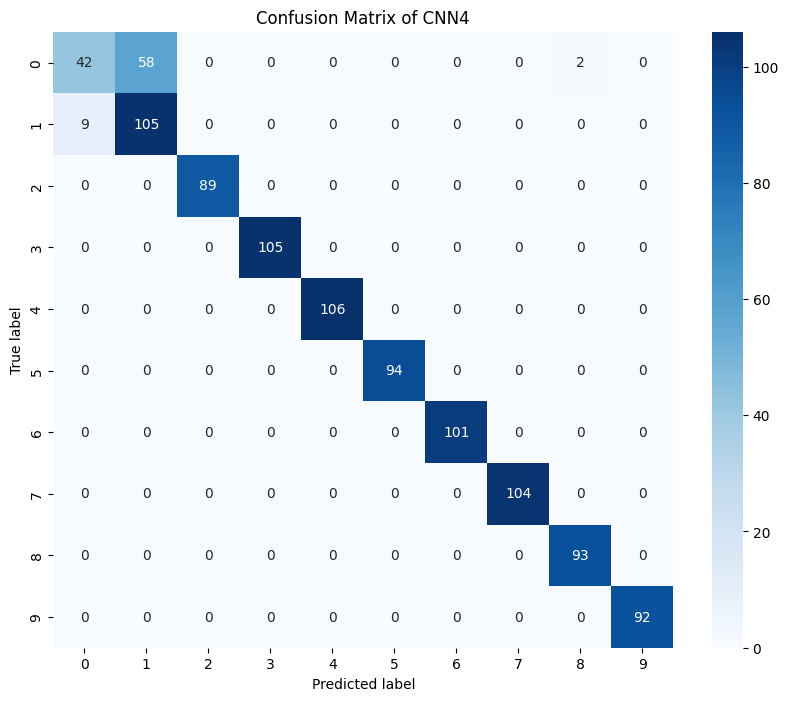

In [44]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of CNN4')
plt.show()

In [45]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
Overall Precision: 0.9394776880852437
Overall Recall: 0.931
Overall F1-Score: 0.9254366310776557


In [74]:
model_to_train.save('cnn3_model.h5')

In [76]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn3_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 90.80%


In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of CNN3')
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


In [69]:
model_to_train.save('cnn2_model.h5')

In [66]:
model_to_train.save('cnn1_model.h5')

In [ ]:
model_to_train.save('lstm_model.h5')

In [54]:

from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Bidirectional, LSTM
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
Bilstm_model = Sequential()

# Add a Bidirectional LSTM layer
Bilstm_model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(data_real_values.shape[1], 2)))
Bilstm_model.add(BatchNormalization())
Bilstm_model.add(Dropout(0.3))

# Add another Bidirectional LSTM layer
Bilstm_model.add(Bidirectional(LSTM(64)))
Bilstm_model.add(BatchNormalization())
Bilstm_model.add(Dropout(0.3))

# Add a Dense layer
Bilstm_model.add(Dense(128, activation='relu'))
Bilstm_model.add(BatchNormalization())
Bilstm_model.add(Dropout(0.3))

# Output layer with 10 neurons for multi-class classification
Bilstm_model.add(Dense(10, activation='softmax'))

In [65]:
model_to_train.save('mlp_model.h5')

In [85]:
model_to_train.save('mlp1_model.h5')

In [91]:
from keras.models import Model
from keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, BatchNormalization, concatenate
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define input shape
input_shape = (data_real_values.shape[1], 2)

# Input layer
input_layer = Input(shape=input_shape)

# CNN layers
cnn_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu')(input_layer)
cnn_layer1 = MaxPooling1D(pool_size=2)(cnn_layer1)
cnn_layer2 = Conv1D(filters=64, kernel_size=3, activation='relu')(cnn_layer1)
cnn_layer2 = MaxPooling1D(pool_size=2)(cnn_layer2)
cnn_layer3 = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_layer2)
cnn_layer3 = MaxPooling1D(pool_size=2)(cnn_layer3)
cnn_output = Flatten()(cnn_layer3)

# MLP layers
mlp_input = Flatten()(input_layer)
mlp_layer1 = Dense(128, activation='relu')(mlp_input)
mlp_layer1 = BatchNormalization()(mlp_layer1)
mlp_layer1 = Dropout(0.3)(mlp_layer1)
mlp_layer2 = Dense(64, activation='relu')(mlp_layer1)
mlp_layer2 = BatchNormalization()(mlp_layer2)
mlp_layer2 = Dropout(0.3)(mlp_layer2)



# Concatenate the outputs of CNN, MLP, and LSTM
combined_layer = concatenate([cnn_output, mlp_layer2])

# Dense layers
dense_layer1 = Dense(128, activation='relu')(combined_layer)
dense_layer1 = BatchNormalization()(dense_layer1)
dense_layer1 = Dropout(0.3)(dense_layer1)
dense_layer2 = Dense(64, activation='relu')(dense_layer1)

# Output layer with 10 neurons for multi-class classification
output_layer = Dense(10, activation='softmax')(dense_layer2)

# Create the model
combined_model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
combined_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
#combined_model.summary()

# Fit the model
combined_model.fit(data_real_values_train, label_train, 
                   validation_data=(data_real_values_test, label_test),
                   epochs=50, batch_size=32,
                   callbacks=[ReduceLROnPlateau(factor=0.2, patience=5, min_lr=0.0001), EarlyStopping(patience=10, restore_best_weights=True)])


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 242ms/step - accuracy: 0.2378 - loss: 1.9509 - val_accuracy: 0.1050 - val_loss: 3.6400 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 238ms/step - accuracy: 0.3827 - loss: 1.4160 - val_accuracy: 0.1010 - val_loss: 4.2445 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 234ms/step - accuracy: 0.4161 - loss: 1.2970 - val_accuracy: 0.1350 - val_loss: 1.8546 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 235ms/step - accuracy: 0.4616 - loss: 1.1615 - val_accuracy: 0.1010 - val_loss: 4.7770 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 235ms/step - accuracy: 0.4450 - loss: 1.1393 - val_accuracy: 0.1170 - val_loss: 3.0711 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 236ms/step - accuracy: 0.5302 - loss: 0.9990 - val_accuracy: 0.2150 - val_loss: 9.4676 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 234ms/step - accuracy: 0.5

In [96]:
model_to_train.save('CNN_AND MLP_model.h5')

In [100]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Dropout, Flatten, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
simple_rnn_model = Sequential()

# Add SimpleRNN layer
simple_rnn_model.add(SimpleRNN(128, input_shape=(data_real_values.shape[1], 2), return_sequences=True))
simple_rnn_model.add(BatchNormalization())
simple_rnn_model.add(Dropout(0.3))

# Add another SimpleRNN layer
simple_rnn_model.add(SimpleRNN(64))
simple_rnn_model.add(BatchNormalization())
simple_rnn_model.add(Dropout(0.3))

# Flatten the output
simple_rnn_model.add(Flatten())

# Add Dense layers
simple_rnn_model.add(Dense(128, activation='relu'))
simple_rnn_model.add(BatchNormalization())
simple_rnn_model.add(Dropout(0.3))
simple_rnn_model.add(Dense(64, activation='relu'))

# Output layer with 10 neurons for multi-class classification
simple_rnn_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = simple_rnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)



/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


KeyboardInterrupt: 

In [ ]:
model_to_train.save('simple_rnn_model.h5')

In [ ]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('simple_rnn_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout, Flatten, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Create a Sequential model
gru_model = Sequential()

# Add GRU layer
gru_model.add(GRU(128, input_shape=(data_real_values.shape[1], 2), return_sequences=True))
gru_model.add(BatchNormalization())
gru_model.add(Dropout(0.3))

# Add another GRU layer
gru_model.add(GRU(64))
gru_model.add(BatchNormalization())
gru_model.add(Dropout(0.3))

# Flatten the output
gru_model.add(Flatten())

# Add Dense layers
gru_model.add(Dense(128, activation='relu'))
gru_model.add(BatchNormalization())
gru_model.add(Dropout(0.3))
gru_model.add(Dense(64, activation='relu'))

# Output layer with 10 neurons for multi-class classification
gru_model.add(Dense(10, activation='softmax'))

# Model to train
model_to_train = gru_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=100, batch_size=32,
    callbacks=callbacks,
)


In [ ]:
model_to_train.save('GRU_model.h5')

In [ ]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('GRU_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, BatchNormalization, concatenate
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define input shape
input_shape = (1014, 2)

# Input layer
input_layer = Input(shape=input_shape)

# CNN layers
cnn_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu')(input_layer)
cnn_layer1 = MaxPooling1D(pool_size=2)(cnn_layer1)
cnn_layer2 = Conv1D(filters=64, kernel_size=3, activation='relu')(cnn_layer1)
cnn_layer2 = MaxPooling1D(pool_size=2)(cnn_layer2)
cnn_layer3 = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_layer2)
cnn_layer3 = MaxPooling1D(pool_size=2)(cnn_layer3)
cnn_output = Flatten()(cnn_layer3)

# MLP layers
mlp_input = Flatten()(input_layer)
mlp_layer1 = Dense(128, activation='relu')(mlp_input)
mlp_layer1 = BatchNormalization()(mlp_layer1)
mlp_layer1 = Dropout(0.3)(mlp_layer1)
mlp_layer2 = Dense(64, activation='relu')(mlp_layer1)
mlp_layer2 = BatchNormalization()(mlp_layer2)
mlp_layer2 = Dropout(0.3)(mlp_layer2)

# LSTM layers
lstm_layer1 = LSTM(128, return_sequences=True)(input_layer)
lstm_layer1 = BatchNormalization()(lstm_layer1)
lstm_layer1 = Dropout(0.3)(lstm_layer1)
lstm_layer2 = LSTM(64)(lstm_layer1)
lstm_layer2 = BatchNormalization()(lstm_layer2)
lstm_layer2 = Dropout(0.3)(lstm_layer2)

# Concatenate the outputs of CNN, MLP, and LSTM
combined_layer = concatenate([cnn_output, mlp_layer2, lstm_layer2])

# Dense layers
dense_layer1 = Dense(128, activation='relu')(combined_layer)
dense_layer1 = BatchNormalization()(dense_layer1)
dense_layer1 = Dropout(0.3)(dense_layer1)
dense_layer2 = Dense(64, activation='relu')(dense_layer1)

# Output layer with 10 neurons for multi-class classification
output_layer = Dense(10, activation='softmax')(dense_layer2)

# Create the model
combined_model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
combined_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
combined_model.summary()

# Fit the model
combined_model.fit(data_real_values_train, label_train, 
                   validation_data=(data_real_values_test, label_test),
                   epochs=100, batch_size=32,
                   callbacks=[ReduceLROnPlateau(factor=0.2, patience=5, min_lr=0.0001), EarlyStopping(patience=10, restore_best_weights=True)])


In [ ]:
model_to_train.save('cnn_mlp_lstm_model.h5')

In [ ]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn_mlp_lstm_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, Bidirectional, BatchNormalization, concatenate
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define input shape
input_shape = (1014, 2)

# Input layer
input_layer = Input(shape=input_shape)

# CNN layers
cnn_layer1 = Conv1D(filters=32, kernel_size=3, activation='relu')(input_layer)
cnn_layer1 = MaxPooling1D(pool_size=2)(cnn_layer1)
cnn_layer2 = Conv1D(filters=64, kernel_size=3, activation='relu')(cnn_layer1)
cnn_layer2 = MaxPooling1D(pool_size=2)(cnn_layer2)
cnn_layer3 = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_layer2)
cnn_layer3 = MaxPooling1D(pool_size=2)(cnn_layer3)
cnn_output = Flatten()(cnn_layer3)

# MLP layers
mlp_input = Flatten()(input_layer)
mlp_layer1 = Dense(128, activation='relu')(mlp_input)
mlp_layer1 = BatchNormalization()(mlp_layer1)
mlp_layer1 = Dropout(0.3)(mlp_layer1)
mlp_layer2 = Dense(64, activation='relu')(mlp_layer1)
mlp_layer2 = BatchNormalization()(mlp_layer2)
mlp_layer2 = Dropout(0.3)(mlp_layer2)

# BiLSTM layers
bilstm_layer = Bidirectional(LSTM(128, return_sequences=True))(input_layer)
bilstm_output = Bidirectional(LSTM(64))(bilstm_layer)

# Concatenate the outputs of CNN, MLP, and BiLSTM
combined_layer = concatenate([cnn_output, mlp_layer2, bilstm_output])

# Dense layers
dense_layer1 = Dense(128, activation='relu')(combined_layer)
dense_layer1 = BatchNormalization()(dense_layer1)
dense_layer1 = Dropout(0.3)(dense_layer1)
dense_layer2 = Dense(64, activation='relu')(dense_layer1)

# Output layer with 10 neurons for multi-class classification
output_layer = Dense(10, activation='softmax')(dense_layer2)

# Create the model
combined_model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
combined_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
combined_model.summary()

# Fit the model
combined_model.fit(data_real_values_train, label_train, 
                   validation_data=(data_real_values_test, label_test),
                   epochs=100, batch_size=32,
                   callbacks=[ReduceLROnPlateau(factor=0.2, patience=5, min_lr=0.0001), EarlyStopping(patience=10, restore_best_weights=True)])


In [ ]:
model_to_train.save('cnn_mlp_Bilstm_model.h5')

In [ ]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn_mlp_Bilstm_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [58]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

#model_to_train = cnn_model
#model_to_train = lstm_model
model_to_train = Bilstm_model
#model_to_train = cnn_lstm_model
#model_to_train = mlp_model
#model_to_train = simpleRNN_model\n",
#model_to_train = gru_model\n",
#model_to_train=CNN_LSTM_model\n",
    
#loss1 = 'sparse_categorical_crossentropy'
#loss2 = 'binary_crossentropy'
#loss3 = keras.losses.BinaryFocalCrossentropy(),
    
#optimizer = keras.optimizers.Adam(learning_rate=0.001) #https://keras.io/api/optimizers/adam/
#optimizer = keras.optimizers.RMSprop(learning_rate=0.001) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/
    
#model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])
#train_history = model_to_train.fit(data_real_values_train, label_train, 
#                                       validation_data = (data_real_values_test, label_test),
#                                      epochs=50, batch_size=32)




callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
   # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

#for model in models:
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
train_history = model_to_train.fit(data_real_values_train, label_train, 
                                       validation_data = (data_real_values_test, label_test),
                                       epochs=50, batch_size=32,
                                       callbacks=callbacks,
                                       )

   


Epoch 1/50


125/125 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.7921 - loss: 0.4322 - val_accuracy: 0.6600 - val_loss: 0.8482 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8022 - loss: 0.4622 - val_accuracy: 0.8200 - val_loss: 0.3298 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.8001 - loss: 0.4291 - val_accuracy: 0.8430 - val_loss: 0.3010 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8435 - loss: 0.3341 - val_accuracy: 0.8880 - val_loss: 0.2299 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.7997 - loss: 0.4320 - val_accuracy: 0.7390 - val_loss: 1.2421 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.8535 - loss: 0.3300 - val_accuracy: 0.6790 - val_loss: 0.7680 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.7906 - loss: 0.4506 - val_

In [59]:
model_to_train.save('Bilstm_model.h5')

In [60]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('Bilstm_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 95.80%


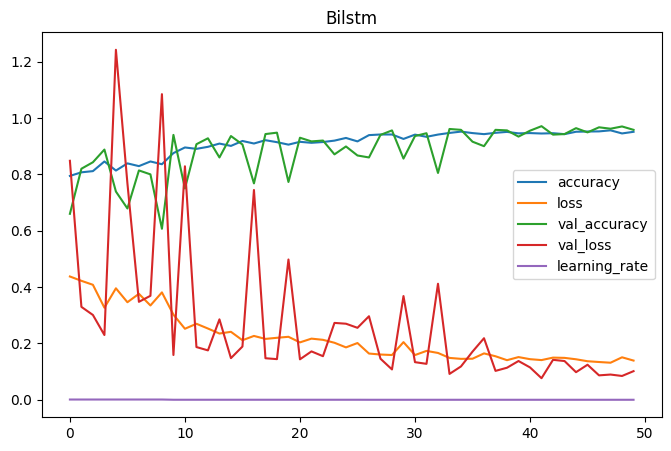

In [61]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'Bilstm')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

In [33]:
label_test.shape

(1000, 1)

In [35]:
data_real_values_test.shape

(1000, 1014, 2)

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 367ms/step


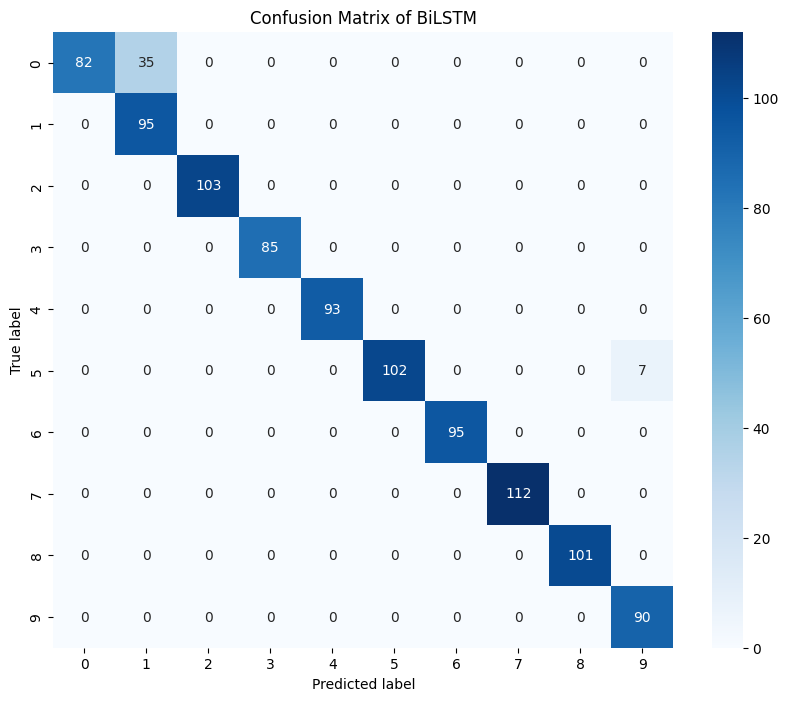

In [64]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of BiLSTM')
plt.show()

In [63]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


 1/32 ━━━━━━━━━━━━━━━━━━━━ 11s 361ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 384ms/step
Overall Precision: 0.9679282315622523
Overall Recall: 0.958
Overall F1-Score: 0.957659235073691


In [ ]:
Spectrogram

In [29]:
input_data=data_real_values

In [ ]:
%pip install librosa

In [ ]:
def train_feature_extractor(
    file_path = 
    #'/workspaces/work/dataset_training_no_aug.h5'
    "/workspaces/work/dataset_training_aug.h5", 
    dev_range = np.arange(0,30, dtype = int), 
    pkt_range = np.arange(0,1000, dtype = int), 
    snr_range = np.arange(20,80)):

                            
    '''
    train_feature_extractor trains an RFF extractor using triplet loss.
    
    INPUT: 
        FILE_PATH is the path of training dataset.
        
        DEV_RANGE is the label range of LoRa devices to train the RFF extractor.
        
        PKT_RANGE is the range of packets from each LoRa device to train the RFF extractor.
        
        SNR_RANGE is the SNR range used in data augmentation. 
        
    RETURN:
        FEATURE_EXTRACTOR is the RFF extractor which can extract features from
        channel-independent spectrograms.
    '''
    
    LoadDatasetObj = LoadDataset()
    
    # Load preamble IQ samples and labels.
    data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)
    #######################################################3
    # data = np.real(data).reshape(data.shape[0], 1, data.shape[1])
    # for i in range(data.shape[0]):
    #     data[i] = calculate_rms(data[i])
    ##########################################################
        
    # Add additive Gaussian noise to the IQ samples.
    #data = awgn(data, snr_range)
    
    ChannelIndSpectrogramObj = ChannelIndSpectrogram()
    
    # Convert time-domain IQ samples to channel-independent spectrograms.
    data = ChannelIndSpectrogramObj.channel_ind_spectrogram(data)
    
    return data, label
    

In [ ]:
# Optionally, you can visualize a spectrogram for one sample
#plt.figure(figsize=(10, 4))
#librosa.display.specshow(librosa.amplitude_to_db(spectrograms[0], ref=np.max), sr=44100, hop_length=512, x_axis='time', y_axis='log')
#plt.colorbar(format='%+2.0f dB')
#plt.title('Spectrogram')
#plt.show()

In [31]:
spectrograms.shape

(5000, 2, 1025, 15)

In [32]:
spectrograms.shape[1]

2

In [33]:
data_real=spectrograms

In [34]:
#SOME PREPROCESSING

data_real.shape
data_real_train, data_real_test, label_train, label_test = train_test_split(data_real, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [35]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import librosa

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization

In [37]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# Assuming your input data is stored in a variable called 'X_train', 'X_test', 'y_train', 'y_test'

# Define CNN model
def create_cnn_model(input_shape):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (1, 1), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(Dropout(0.3))
    model.add(layers.Conv2D(64, (1, 1), activation='relu'))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(Dropout(0.3))
    model.add(layers.Conv2D(128, (1, 1), activation='relu'))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(layers.Flatten())
    model.add(Dropout(0.3))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))
    return model

# Initialize model
input_shape = (2,1025, 15)  # Input shape (channels, frequency bins, time bins)
cnn_model = create_cnn_model(input_shape)


# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]
tf.keras.backend.get_session().run(tf.global_variables_initializer())

# Compile the model
model_to_train.compile(optimizer='RMSprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_train, label_train, 
    validation_data=(data_real_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)



Train on 4000 samples, validate on 1000 samples
Epoch 1/50
3968/4000 [============================>.] - ETA: 0s - loss: 14.3659 - acc: 0.0968

FailedPreconditionError: Error while reading resource variable RMSprop/lr from Container: localhost. This could mean that the variable was uninitialized. Not found: Container localhost does not exist. (Could not find resource: localhost/RMSprop/lr)
	 [[node RMSprop/lr/Read/ReadVariableOp (defined at <ipython-input-37-a9ede0bfde32>:44)  = ReadVariableOp[dtype=DT_FLOAT, _device="/job:localhost/replica:0/task:0/device:CPU:0"](RMSprop/lr)]]

Caused by op 'RMSprop/lr/Read/ReadVariableOp', defined at:
  File "/opt/conda/envs/project/lib/python3.6/runpy.py", line 193, in _run_module_as_main
    "__main__", mod_spec)
  File "/opt/conda/envs/project/lib/python3.6/runpy.py", line 85, in _run_code
    exec(code, run_globals)
  File "/opt/conda/envs/project/lib/python3.6/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/opt/conda/envs/project/lib/python3.6/site-packages/traitlets/config/application.py", line 664, in launch_instance
    app.start()
  

: 

In [41]:
def create_cnn_model(input_shape):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(Dropout(0.3))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))
    return model

# Model to train
#model_to_train = models

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=100, batch_size=32,
    callbacks=callbacks,
)


NameError: name 'model' is not defined